# Quick-look for simulations

This notebook can be used to have a quicklook at the that product for the simulations.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [83]:
# Built-in
import os
import sys
import glob

# PlatoSim dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# PlatoSim methods
from platosim.hpc          import HPC
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:60% !important; }</style>"))

---
## Introduction
---

When scripting in Python while analysing your PlatoSim simulations, it can be very useful to use the two PlatoSim paths that you have globally exported (the latter in particular since your simulations is saved to the working directory by default):

In [16]:
os.getenv('PLATO_PROJECT_HOME')

'/lhome/nicholas/software/PlatoSim3'

In [17]:
os.getenv('PLATO_WORKDIR')

'/lhome/nicholas/software/workdir/'

To be completely independent on operation system, we further use `pathlib.Path` objects. E.g. let's define the directory for which all data of this tutorial is stored:

In [ ]:
path = Path(os.getcwd()) / 'data'
path

In this tutotial we assume that you have used `platonium` to generate a batch of simulated light curves for one target star covering each camera and mission quarter. 

To visualise and/or reduce your data, PlatoSim provides the Python class called `LightCurve`. This class has two "modes": a `single` mode to load only one 90-d camera light curve, and a `multi` mode to hadle all light curves simulated per target star. The methods of the `LightCurve` class can found with:

In [41]:
getFunctions(LightCurve)

LightCurve functions
__del__
__init__
_unit_add
_unit_convert
_units
axes_mask_updates
axes_quarter_marks
bin
bin_1d
bin_lc


We note that some of these are still being tested and validated. The methods shown in this notebook have been thoroughly tested.

---
## Single mode
---

Throughout this notebook we look at a variable star with ID 1001 that was observed by 12 N-CAMs for a duration of 2 years (i.e. 8 mission quarters). This leave us with 96 simulated 90-day light curves. 

We start with creating a `LightCurve` object, loading in the first light curve in the `data/mocka` folder:

In [77]:
lc = LightCurve(path / 'mocka' / '000001001_Ncam2.5_Q1.hdf5', mode='single')

### Obs information

When extracting data for a specific file, it can be useful to quickly fetch the `(group, camera, quarter)` IDs that you used to launch `platonium`. You can fetch this information easily with the method `obs()`:

In [79]:
lc.obs()

(2, 5, 1)

For each mission quarter simulation, a `.table` file is generated containing a small overview of the specific simulation. We can see the inforamtion for one such table with the `star()` method:

In [80]:
lc.star().T

,0
ID,1001
gaiaDR3,2895039202841802368
ra,96.696809
dec,-29.741198
mag,15.320604
group,2
camera,5
quarter,1
ccd,4
xCCD,139.768446


The table displays among others the CCD ID (`ccd`), the pixel positions (`xCCD` and `yCCD`), the focal plane coordinates (`xFP` and `yFP` in mm), the number of stellar contaminants (`ncon`), and stellar pollution ratio (`SPR`).

### Fetch data

With the `lc` object we can fetch the time series, or the time and flux column independently:

In [53]:
lc.data().head()

,time,flux
0,18.75,249.243106
1,43.75,242.547470
2,68.75,238.530107
3,93.75,245.091826
4,118.75,232.437098


In [54]:
lc.time().head()

0     18.75
1     43.75
2     68.75
3     93.75
4    118.75
Name: time, dtype: float64

In [55]:
lc.flux().head()

0    249.243106
1    242.547470
2    238.530107
3    245.091826
4    232.437098
Name: flux, dtype: float64

### Visualise data

We can plot the light curve with the method `plot()` and for example show the 1-hour bins of the time series:

<IPython.core.display.Javascript object>


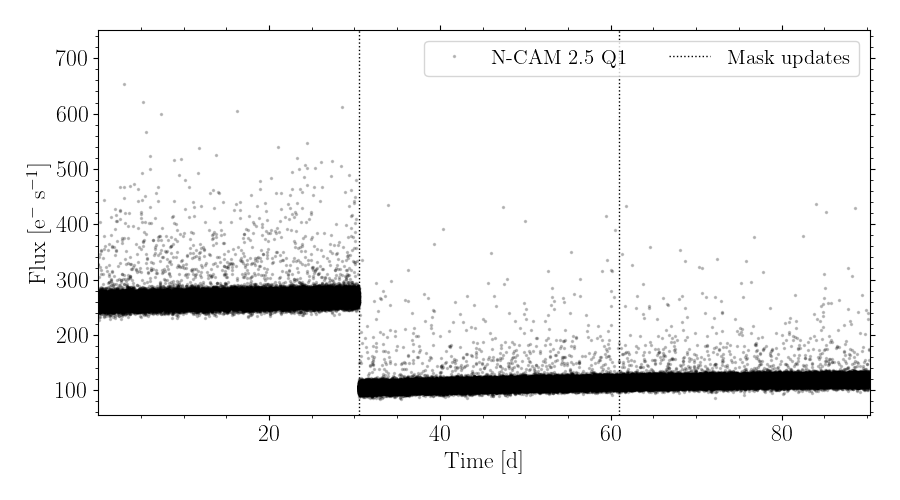

In [62]:
fig, ax = lc.plot(median_filter=1)

### Post-processing

In case of flux jumps (e.g. due to mask updates), you can sticth the light curve with the method `stitch()`:

<IPython.core.display.Javascript object>


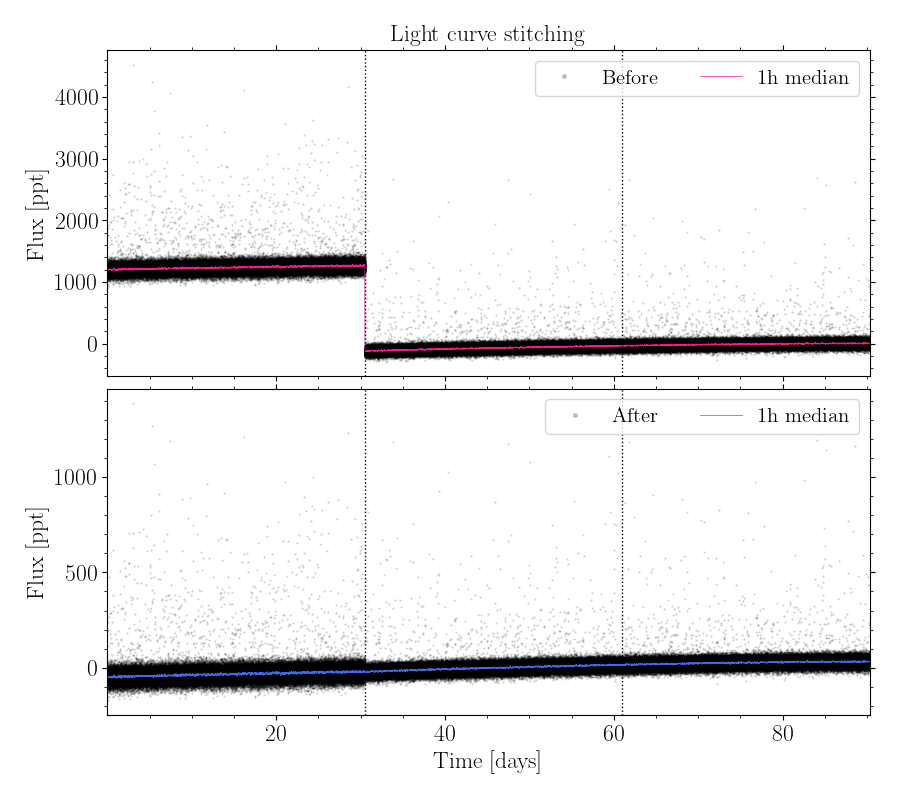

In [73]:
df = lc.stitch(replace=True, plot=True)

You can detrend the light curve (in segments of each mask-update) with the method `detrend()`:

<IPython.core.display.Javascript object>


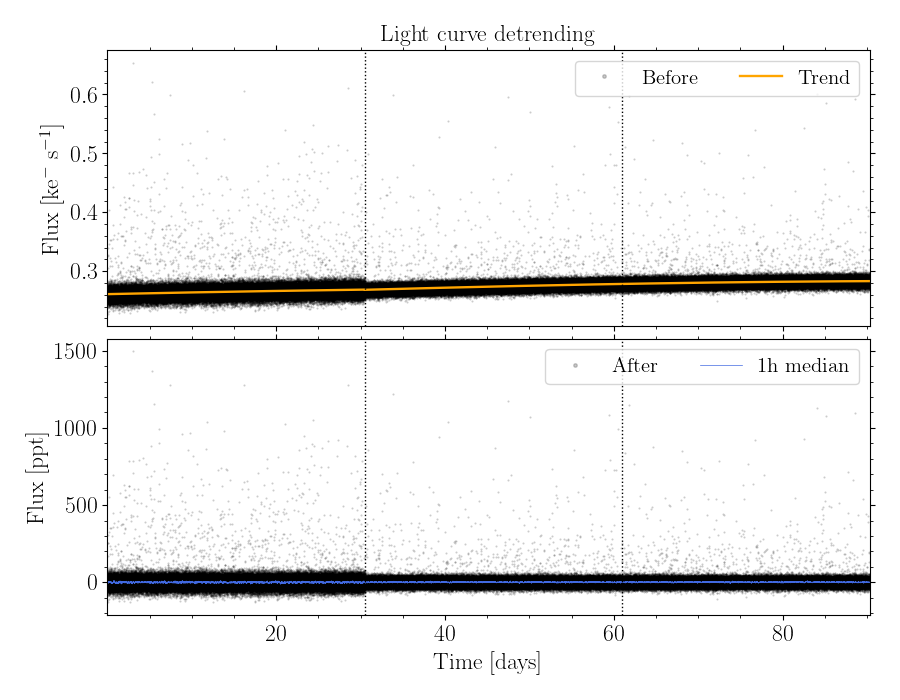

In [74]:
df = lc.detrend(model='poly', segments=True, replace=True, plot=True)

You can remove outliers (due to photon noise and cosmic ray hits) using the `clip()` method:

<IPython.core.display.Javascript object>


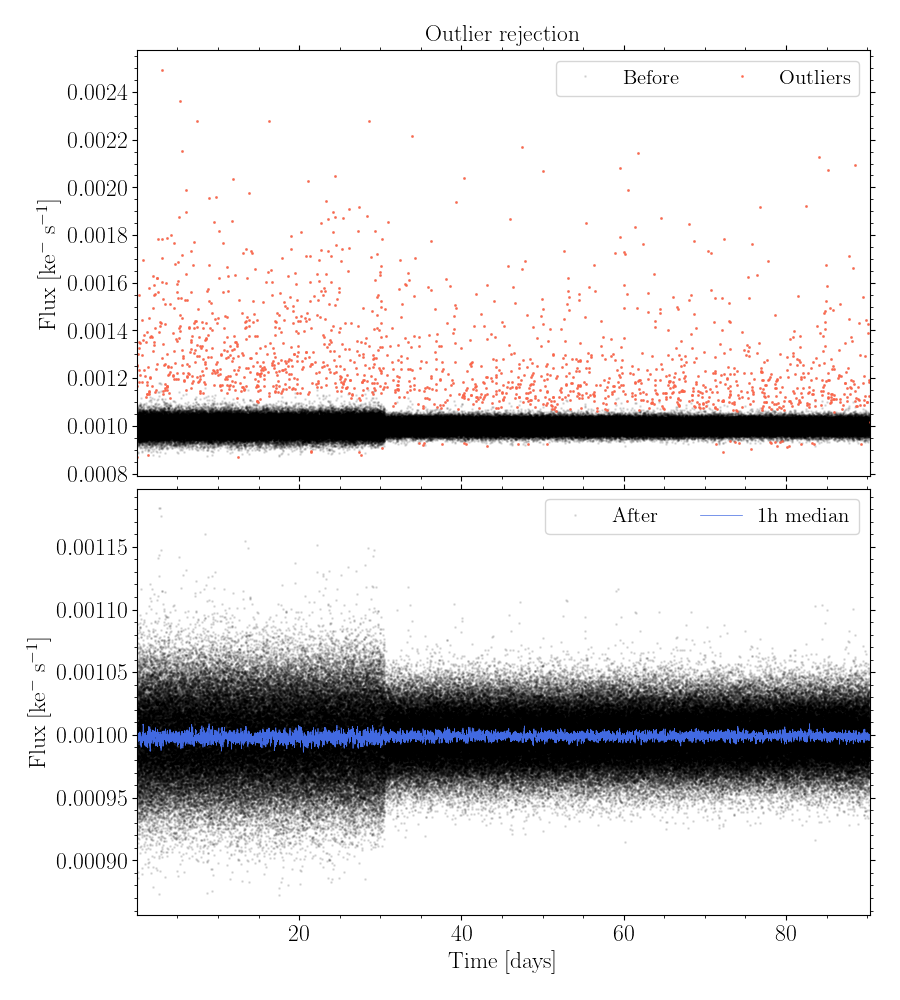

In [75]:
df = lc.clip(model='wotan', sigma_lower=3, sigma_upper=3, plot=True)

---
## Multi mode
---

Initialise the `LightCurve` object and check about light curves we have for this target:

In [70]:
lcs = LightCurve(idir, mode='multi')
files = lcs.files(suffix='hdf5')
len(files)

96

### Simulation statistics

From the single-mode we have seen the information stored in each simulation table. However, instead of having 96 individual files, it is much handier to have a single file to search information from. Hence, we can merge to one single overview table and save it to a feather file on disk with the method `stat_sim_table()`:

In [33]:
ofile = path / 'table.ftr'
df = lcs.stat_sim_table(ofile=ofile, clean=False)
df.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  2.44it/s]                                                                                                                       


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1001,2895039202841802368,96.696809,-29.741198,15.320604,1,1,2,3,124.846678,1926.435602,10.960419,3.547240,-47.804159,1,0.160006
1,1001,2895039202841802368,96.696809,-29.741198,15.320604,1,1,3,1,2701.384774,1583.259944,16.544682,-49.924926,53.981321,1,0.108677
2,1001,2895039202841802368,96.696809,-29.741198,15.320604,1,1,6,3,125.070277,1926.560116,10.959987,3.551265,-47.801918,1,0.098602
3,1001,2895039202841802368,96.696809,-29.741198,15.320604,1,1,7,1,2701.319406,1582.985251,16.545284,-49.923749,53.986265,1,0.145121
4,1001,2895039202841802368,96.696809,-29.741198,15.320604,1,2,2,3,135.484920,1939.533264,10.911218,3.738729,-47.568401,1,0.086653


It possible to remove the (96) redundant `.table` files during the process using `clean=True`, however, to avoid deleting them for this tutorial we set this argument to `False`.

### Visualise light curves

A tip is to use the multi-mode and simply investigate a certain light curve using `files` containing a list of filenames:

<IPython.core.display.Javascript object>


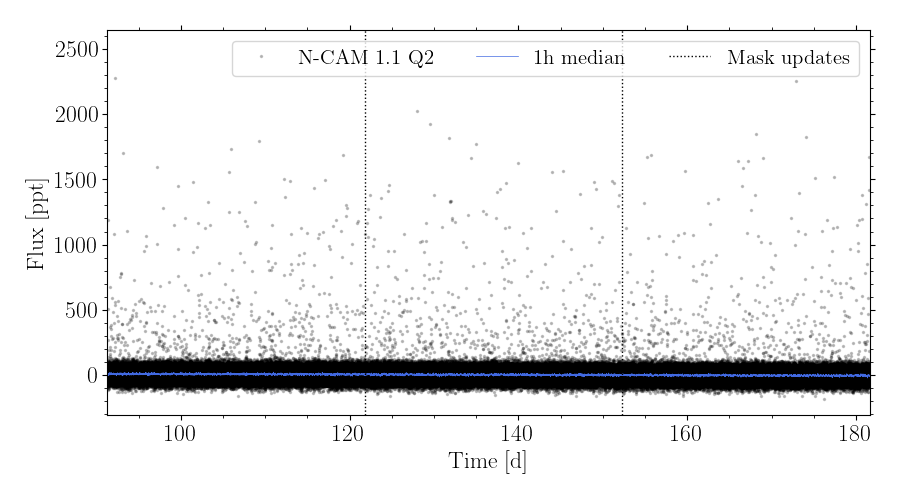

In [26]:
lc = LightCurve(files[0], mode="single")
fig, ax = lc.plot(flux_unit='ppt', median_filter=1)

The power of the multi-mode is that we can plot all light curve coherently together to investigate the simulations. The method called `plot_multi()` takes the `group`, `camera`, and `quarter` as input, allowing you to show different configurations of the observation. Let's plot first all light curves observed by camera ID 1 (across all camera groups):

<IPython.core.display.Javascript object>


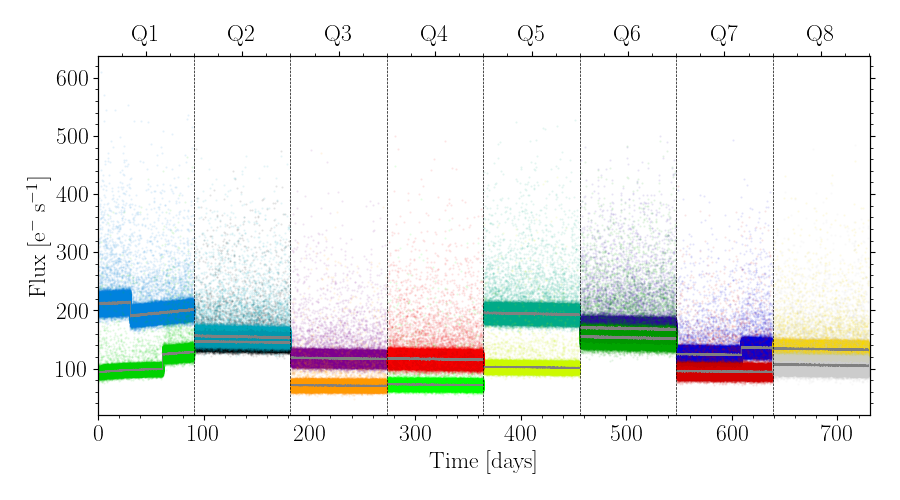

In [71]:
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=1, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

As expected from the 12 N-CAM visibility, camera group 4 do not observe the target all the time. Let's plot all light curves and compare:

<IPython.core.display.Javascript object>


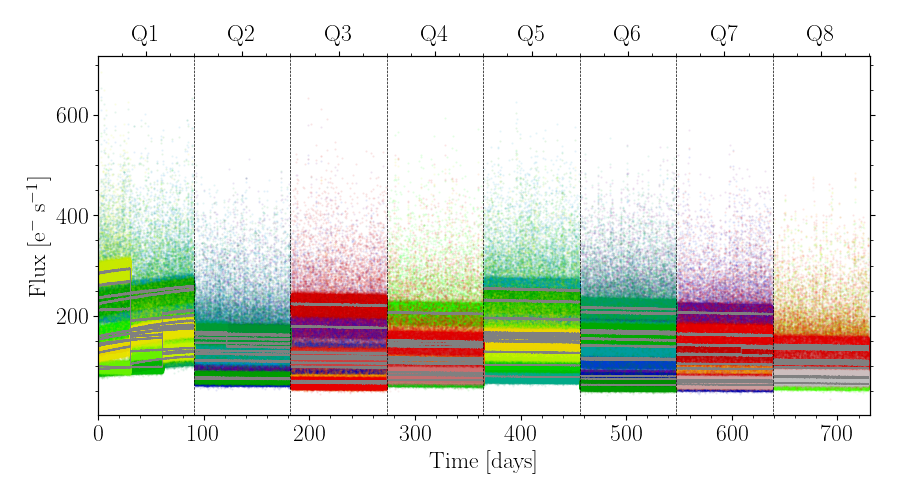

In [28]:
fig, ax = lcs.plot_multi(suffix='hdf5', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.1, figsize=(9,5))

You may have noticed the flux "jumps" happening in Q1. These are due to aperture mask-updates for the on-board photometry algorith that was used, which we allowed to happen every 30 days.

### Post-processing

In [ ]:
lc = lcs.merge(suffix='hdf5', 
               verbose=True,
               detrend='poly',
               flux_group_mean=True, 
               binsize=0.2, 
               clip=False, #True,
               flux_offset=True, 
               flux_err=True, 
               ofile=f'{idir}/lc_{star}.ftr')

In [80]:
lc.plot(input_model=True, flux_unit='ppm', median_filter=1, alpha=0.1, figsize=(9,6));

<IPython.core.display.Javascript object>

In [ ]:
# Introduce data gaps
df = lc.gaps(f'{path}/input/instrumentGAP.tab', replace=True)
df = df.dropna()
df.time /= 86400

# Load variable template
dm = pd.read_feather(f'{path}/simulations/test/varsource/{star}/varsource_001_pulsations.ftr')
dv = pd.DataFrame()
dv['time'] = df.time
dv['dmag'] = ns.timeSeriesFromFourier(df.time, dm.freq, dm.ampl, dm.phase, power=2.2)
dv['flux'] = (10**(-0.4*dv.dmag) - 1) * 1e6

# Plot final light curve
fig, ax = lc.plot(flux_unit='ppm', median_filter=False)
ax.plot(dv.time, dv.flux, '-', c='orange', lw=1);

---
## High performance computing (HPC)
---

We generally recommend to use a computing cluster to run your simulations in multiple CPUs/cores in parallel, however, below we quickly show how you can laucnh a batch of simulations using the Python class `HPC()`. Using this class, `platonium` can be launch with a parameterisation file containing the following 4 columns: {`id`, `group`, `camera`, `quarter`}. The experienced user may already see that this is in fact the four mandatory arguments parsed to `platonium`. We provide an example parameterisation file together with this notebook called `cluster_ncam.data`.

In order to successfully `hpc.run()` your simulations, you need (as usual) to have a project folder called `test0`. Inside the folder `test0/input`, you need to have the `cluster_ncam.data` located together with your star catalogue(s) and `inputfile.yaml` (just as you normally would using `platonium`). You can place your variable source file anywhere on your system, since you need to provide the full path to this file. Lastly, by default, `platonium` will save your simulations to your `$PLATO_WORKDIR/output/<ID-9digit>` folder, but you can choose another location with the argument `odir` below.
 
Below we show how you would launch parallel simulations on your own laptop given the above information:

```
# Load variable source file
varfile = path / 'varsource_gdor.txt'

# Arguments to parse
kwargs = (f'--seed 12345 performance expected --varfile {varfile} -w')

# Set output directory
odir = path / 'simulations'

# Launch simulations on 6 CPUs (check your system capacity)
hpc = HPC('', cpus=6)
hpc.run(script='platonium', param_file='cluster_ncam.data', odir=odir, kwargs=kwargs) 
```